# K-Nearest Neighbors Classifier

**What you'll learn:** How KNN makes predictions purely from memory — no parameters, no training loop, just geometry.

**Prerequisites:** Python, NumPy basics, the idea of a distance between two points.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import ipywidgets as widgets
from IPython.display import display

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
})

COLORS = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]
np.random.seed(42)

## 1 · Core Idea: Classify by Proximity

Most ML algorithms *learn* parameters from data — they fit weights, coefficients, tree splits. KNN does none of that.

> **Key insight:** KNN memorizes the entire training set. At prediction time it asks: *"what class do my k closest neighbors belong to?"* — and votes.

This is called **instance-based** or **lazy learning** because all the work happens at query time, not at training time.

### Why does this work?

If the data obeys a **smoothness assumption** — nearby points tend to have the same label — then knowing your neighbors tells you a lot about yourself. KNN is the most direct embodiment of this idea.

---

## 2 · The Distance Metric

"Nearest" requires a ruler. The most common choice is **Euclidean distance** (straight-line distance in feature space).

For two points $\mathbf{x} = (x_1, x_2, \ldots, x_p)$ and $\mathbf{x'} = (x'_1, x'_2, \ldots, x'_p)$ in $p$ dimensions:

$$
d(\mathbf{x}, \mathbf{x'}) = \sqrt{\sum_{j=1}^{p} (x_j - x'_j)^2}
$$

This generalizes to the **Minkowski distance** of order $q$:

$$
d_q(\mathbf{x}, \mathbf{x'}) = \left( \sum_{j=1}^{p} |x_j - x'_j|^q \right)^{1/q}
$$

| $q$ | Name | Shape of "ball" |
|-----|------|-----------------|
| 1   | Manhattan | Diamond (L1) |
| 2   | Euclidean | Circle / Sphere |
| $\infty$ | Chebyshev | Square / Cube |

> **Key insight:** The choice of distance metric implicitly defines what "similar" means. Euclidean treats all features symmetrically — so **feature scaling matters**. A feature with range 0–1000 will dominate one with range 0–1 unless you normalize.

---

## 3 · The Decision Rule

Given a query point $\mathbf{x}_q$:

1. **Find** the $k$ training points closest to $\mathbf{x}_q$ — call this set $\mathcal{N}_k(\mathbf{x}_q)$
2. **Vote:** each neighbor contributes its label
3. **Predict** the majority class:

$$
\hat{y} = \underset{c}{\arg\max} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} \mathbf{1}[y_i = c]
$$

where $\mathbf{1}[\cdot]$ is the indicator function (1 if true, 0 otherwise).

### Notation

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}_q$ | Query (test) point |
| $k$ | Number of neighbors to consult |
| $\mathcal{N}_k(\mathbf{x}_q)$ | The $k$ nearest neighbors of $\mathbf{x}_q$ |
| $\hat{y}$ | Predicted class label |
| $c$ | A candidate class label |

### Effect of $k$

- **Small $k$ (e.g., k=1):** Very jagged decision boundary — the model memorizes noise → **overfitting**
- **Large $k$ (e.g., k=N):** Very smooth boundary — always predicts the global majority class → **underfitting**
- **Optimal $k$:** Found by cross-validation

---

## 4 · Dataset

We'll use a 2D, 3-class dataset — two features and three clusters. Two dimensions means we can draw everything, and three classes makes the multi-class vote meaningful.

---

In [2]:
X, y = make_blobs(
    n_samples=300,
    centers=[[-2, -2], [2, 2], [-2, 3]],
    cluster_std=1.0,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"Classes:          {np.unique(y)}")

Training samples: 210
Test samples:     90
Classes:          [0 1 2]


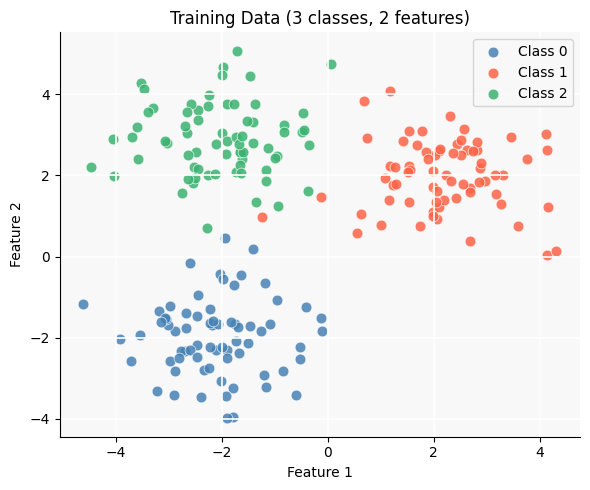

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in zip(np.unique(y_train), COLORS):
    mask = y_train == cls
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=color, label=f"Class {cls}", edgecolors="white",
               linewidth=0.5, s=60, alpha=0.85)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Training Data (3 classes, 2 features)")
ax.legend()
plt.tight_layout()
plt.show()

## 5 · From-Scratch Implementation

KNN has **no training step** — `fit` just stores the data. All computation is deferred to `predict`.

---

In [4]:
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _euclidean_distances(self, x):
        # x: (p,)  →  distances: (n_train,)
        diff = self.X_train - x          # broadcast: (n_train, p)
        return np.sqrt((diff ** 2).sum(axis=1))

    def predict_single(self, x):
        dists = self._euclidean_distances(x)
        nn_idx = np.argsort(dists)[: self.k]  # indices of k smallest distances
        nn_labels = self.y_train[nn_idx]
        vote = Counter(nn_labels)
        return vote.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [5]:
knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)

train_acc = knn.score(X_train, y_train)
test_acc  = knn.score(X_test,  y_test)

print(f"k = {knn.k}")
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}")

k = 5
Train accuracy: 0.990
Test  accuracy: 0.967


## 6 · Decision Boundary

A **decision boundary** is the surface in feature space where the predicted class changes. For KNN it's never a straight line — it follows the geometry of the training data.

We visualize it by classifying a dense grid of points and coloring each pixel by predicted class.

---

In [6]:
def make_meshgrid(X, margin=1.0, step=0.08):
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step),
    )
    return xx, yy


def plot_decision_boundary(ax, model, X, y, title):
    xx, yy = make_meshgrid(X)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points).reshape(xx.shape)

    cmap_bg = plt.cm.colors.ListedColormap(["#d4e8f5", "#fdd5d0", "#c8ebd8"])
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

    for cls, color in zip(np.unique(y), COLORS):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=color,
                   edgecolors="white", linewidth=0.5, s=45, alpha=0.9,
                   label=f"Class {cls}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.legend(fontsize=8)

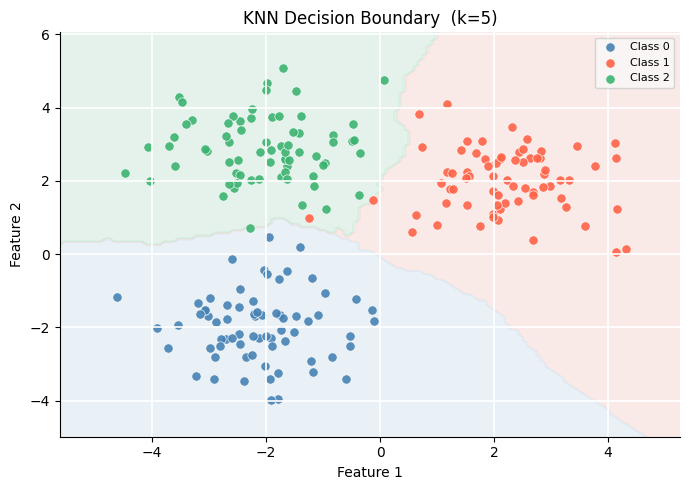

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(ax, knn, X_train, y_train,
                       title=f"KNN Decision Boundary  (k={knn.k})")
plt.tight_layout()
plt.show()

## 7 · Effect of $k$: Bias–Variance Trade-off

The single most important hyperparameter in KNN is $k$.

- **$k=1$:** Each training point is its own Voronoi cell → zero training error, highly overfit
- **$k \to N$:** All points vote → boundary collapses to a single flat region

The plot below shows four values side by side so the transition is clear.

---

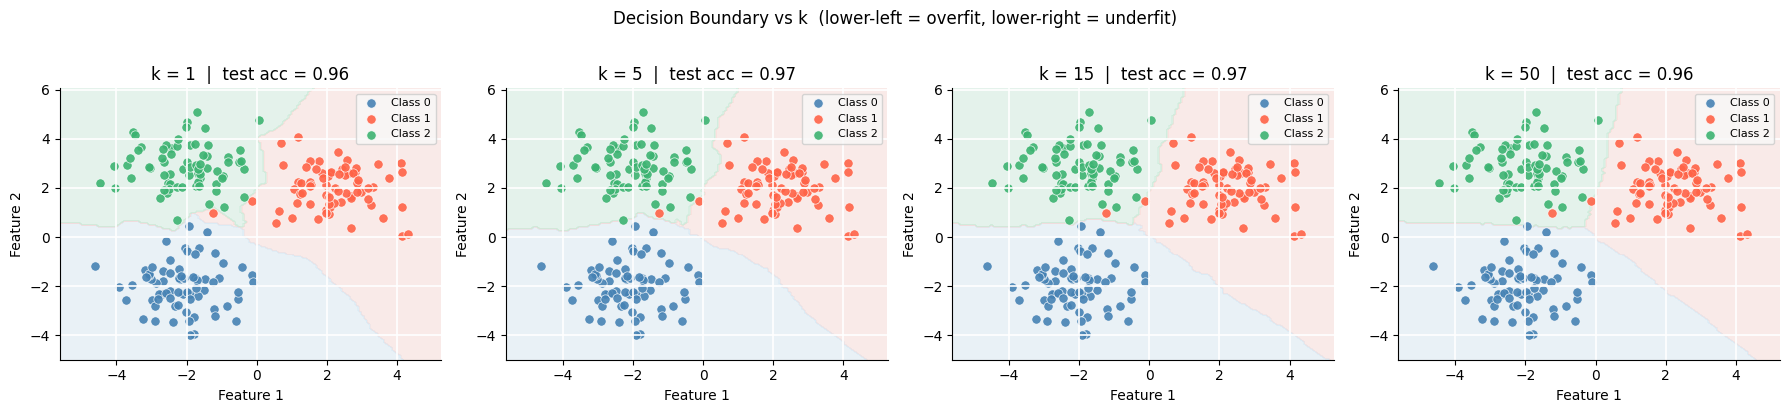

In [8]:
k_values = [1, 5, 15, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, k in zip(axes, k_values):
    model = KNNClassifier(k=k).fit(X_train, y_train)
    test_a = model.score(X_test, y_test)
    plot_decision_boundary(
        ax, model, X_train, y_train,
        title=f"k = {k}  |  test acc = {test_a:.2f}"
    )

plt.suptitle("Decision Boundary vs k  (lower-left = overfit, lower-right = underfit)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8 · Choosing $k$ by Cross-Validation

Rather than guessing $k$, we sweep a range and pick the value with the best validation accuracy. This is the standard approach.

---

In [9]:
k_range = range(1, 41)
train_accs, test_accs = [], []

for k in k_range:
    m = KNNClassifier(k=k).fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

best_k = k_range.start + int(np.argmax(test_accs))
print(f"Best k = {best_k}  →  test accuracy = {max(test_accs):.3f}")

Best k = 3  →  test accuracy = 0.978


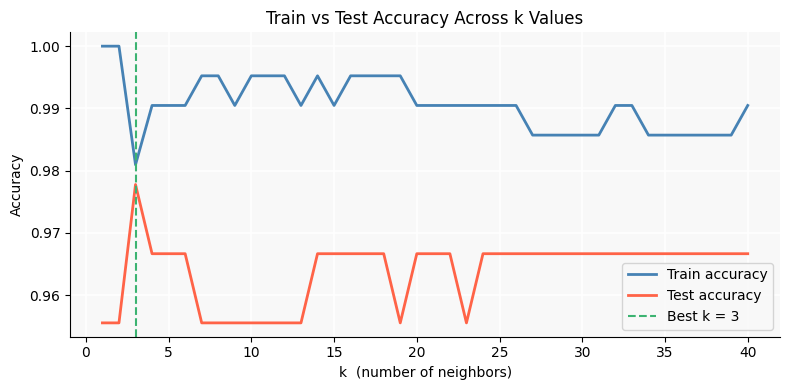

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), train_accs, color="steelblue",  label="Train accuracy", linewidth=2)
ax.plot(list(k_range), test_accs,  color="tomato",     label="Test accuracy",  linewidth=2)
ax.axvline(best_k, color="mediumseagreen", linestyle="--",
           label=f"Best k = {best_k}")
ax.set_xlabel("k  (number of neighbors)")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy Across k Values")
ax.legend()
plt.tight_layout()
plt.show()

> **Key insight:** As $k$ increases, train accuracy *drops* but test accuracy first rises then falls. The crossing point is the sweet spot — enough smoothing to generalize, not so much that we lose discriminative structure.

---

## 9 · Evaluation — Confusion Matrix

Accuracy is a single number. A **confusion matrix** shows *which* classes get confused with each other — much more informative.

---

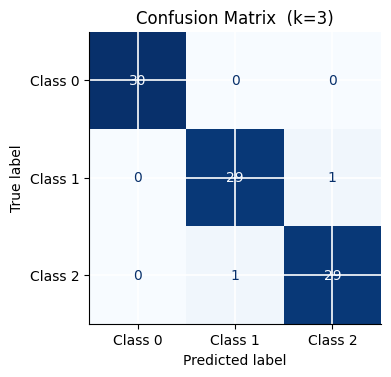

Overall test accuracy: 0.978
  Class 0 accuracy: 1.000
  Class 1 accuracy: 0.967
  Class 2 accuracy: 0.967


In [11]:
best_model = KNNClassifier(k=best_k).fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Class 0", "Class 1", "Class 2"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix  (k={best_k})")
plt.tight_layout()
plt.show()

print(f"Overall test accuracy: {np.mean(y_pred == y_test):.3f}")
per_class = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(per_class):
    print(f"  Class {i} accuracy: {acc:.3f}")

## 10 · Interactive Widget — Explore $k$

Use the slider to see how the decision boundary evolves as $k$ changes. Watch how rough edges (small $k$) smooth out into broad regions (large $k$).

---

In [12]:
def interactive_knn(k):
    model = KNNClassifier(k=k).fit(X_train, y_train)
    test_a = model.score(X_test, y_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_decision_boundary(
        ax, model, X_train, y_train,
        title=f"k = {k}   |   test accuracy = {test_a:.3f}"
    )
    plt.tight_layout()
    plt.show()


k_slider = widgets.IntSlider(
    value=5, min=1, max=50, step=1,
    description="k:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)

out = widgets.interactive_output(interactive_knn, {"k": k_slider})
display(widgets.VBox([k_slider, out]))

## 11 · Computational Cost

KNN's simplicity comes at a cost: **prediction is expensive**.

For each query point, we must compute distances to *every* training point:

$$
\text{Prediction cost} = O(n_{\text{train}} \cdot p)
$$

where $n_{\text{train}}$ is the number of training points and $p$ is the number of features. Compare to a trained linear model: $O(p)$ per query.

**Practical mitigations:**
- **KD-trees / Ball trees:** Spatial indexing structures that reduce average-case lookup to $O(\log n)$
- **Approximate nearest neighbors (ANN):** Faiss, Annoy, ScaNN — trade tiny accuracy for massive speed
- **Dimensionality reduction:** PCA or UMAP before KNN to shrink $p$

> **Key insight:** KNN is excellent for small-to-medium datasets and surprisingly powerful as a baseline. At scale (millions of points, hundreds of features) you'll want ANN libraries.

---

## 12 · Summary

| Concept | Key Idea |
|---------|----------|
| **Lazy learning** | No training step — the dataset *is* the model |
| **Euclidean distance** | $d(\mathbf{x}, \mathbf{x'}) = \sqrt{\sum_j (x_j - x'_j)^2}$ — the default ruler |
| **Decision rule** | Majority vote among $k$ nearest neighbors |
| **Small $k$** | Complex, jagged boundary → overfitting |
| **Large $k$** | Smooth boundary → underfitting |
| **Choosing $k$** | Sweep values, pick by validation accuracy |
| **Feature scaling** | Essential — unscaled features distort distances |
| **Prediction cost** | $O(n \cdot p)$ — grows with dataset size |
| **Smoothness assumption** | Works when nearby points share labels |
| **Confusion matrix** | Reveals which classes are confused, not just overall accuracy |